# 02 — Audio Inspection

Waveform / FFT / spectrogram / log-mel / CQT (and MFCC / gammatone) for representative clips.

Does **not** cache millions of spectrograms or train models.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.audio_io import read_audio, to_mono
from src.features.spectrogram import compute_spectrogram
from src.features.mel import compute_mel
from src.features.cqt import compute_cqt
from src.features.mfcc import compute_mfcc
from src.features.gammatone import compute_gammatone
from src.features.config import load_feature_config

CFG = load_feature_config()
AUDIO_EXTS = {'.wav', '.flac', '.mp3', '.ogg'}
RAW = ROOT / 'data' / 'raw'

def pick_representative(dataset: str, n: int = 1):
    root = RAW / dataset
    if not root.exists():
        return []
    files = [p for p in sorted(root.rglob('*')) if p.is_file() and p.suffix.lower() in AUDIO_EXTS]
    return files[:n]

repr_files = {}
for ds in ['vtuad', 'deepship', 'qiandaoear22', 'shipsear']:
    repr_files[ds] = pick_representative(ds, 1)
repr_files

{'vtuad': [WindowsPath('D:/TinyShip-Finger/data/raw/vtuad/inclusion_2000_exclusion_4000/test/audio/background/0.wav')],
 'deepship': [WindowsPath('D:/TinyShip-Finger/data/raw/deepship/_github_partial/Cargo/103.wav')],
 'qiandaoear22': [WindowsPath('D:/TinyShip-Finger/data/raw/qiandaoear22/001/20220624101843_S_No7_N_S_0_label__0__1 - ╕▒▒╛.wav')],
 'shipsear': []}

In [2]:
def inspect_file(path: Path, max_seconds: float = 5.0):
    y, sr = read_audio(path)
    y = to_mono(y)
    n = min(len(y), int(max_seconds * sr))
    y = y[:n]
    t = np.arange(len(y)) / sr

    spec = compute_spectrogram(y, sr)
    mel = compute_mel(y, sr)
    cqt = compute_cqt(y, sr)
    mfcc = compute_mfcc(y, sr)
    gt = compute_gammatone(y, sr)

    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes[0, 0].plot(t, y)
    axes[0, 0].set_title(f'Waveform — {path.name}')
    freqs = np.fft.rfftfreq(len(y), d=1.0 / sr)
    axes[0, 1].semilogy(freqs, np.abs(np.fft.rfft(y)) + 1e-12)
    axes[0, 1].set_title('FFT magnitude')
    axes[1, 0].imshow(spec, aspect='auto', origin='lower')
    axes[1, 0].set_title('Spectrogram (dB)')
    axes[1, 1].imshow(mel, aspect='auto', origin='lower')
    axes[1, 1].set_title('Log-mel')
    axes[2, 0].imshow(cqt, aspect='auto', origin='lower')
    axes[2, 0].set_title('CQT')
    axes[2, 1].imshow(np.vstack([mfcc, gt[: min(20, gt.shape[0])]]), aspect='auto', origin='lower')
    axes[2, 1].set_title('MFCC (+ gammatone preview)')
    plt.tight_layout()
    plt.show()
    print('sr=', sr, 'n=', len(y), 'cfg=', {k: CFG[k] for k in ('sample_rate','hop_length','n_bins','n_mfcc','fmin','fmax')})

### vtuad


C:\Users\Arbi\.conda\envs\tinyship\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=32768 is too large for input signal of length=32000
  warnings.warn(


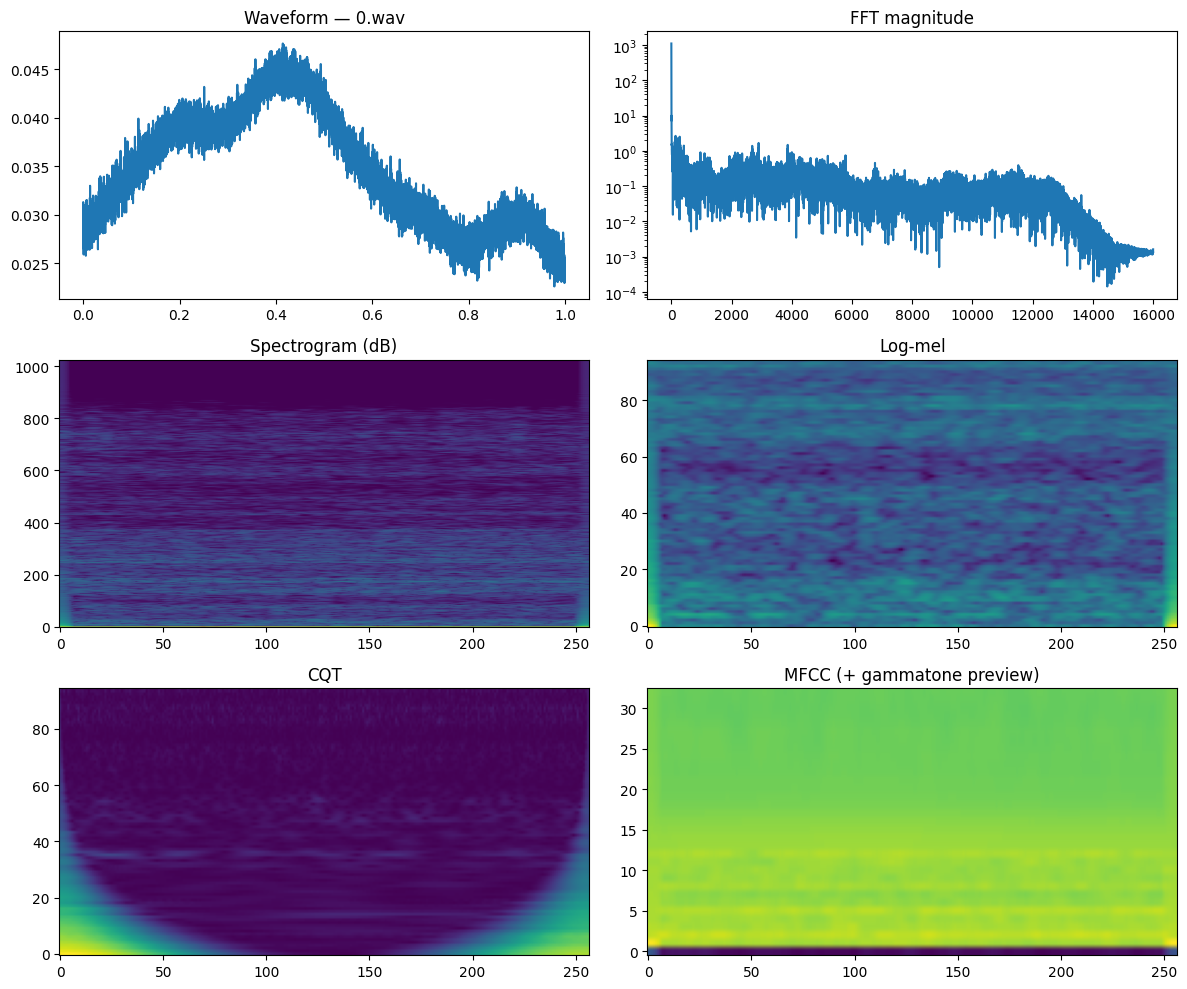

sr= 32000 n= 32000 cfg= {'sample_rate': 32000, 'hop_length': 125, 'n_bins': 95, 'n_mfcc': 13, 'fmin': 18.0, 'fmax': 4186.0}
### deepship


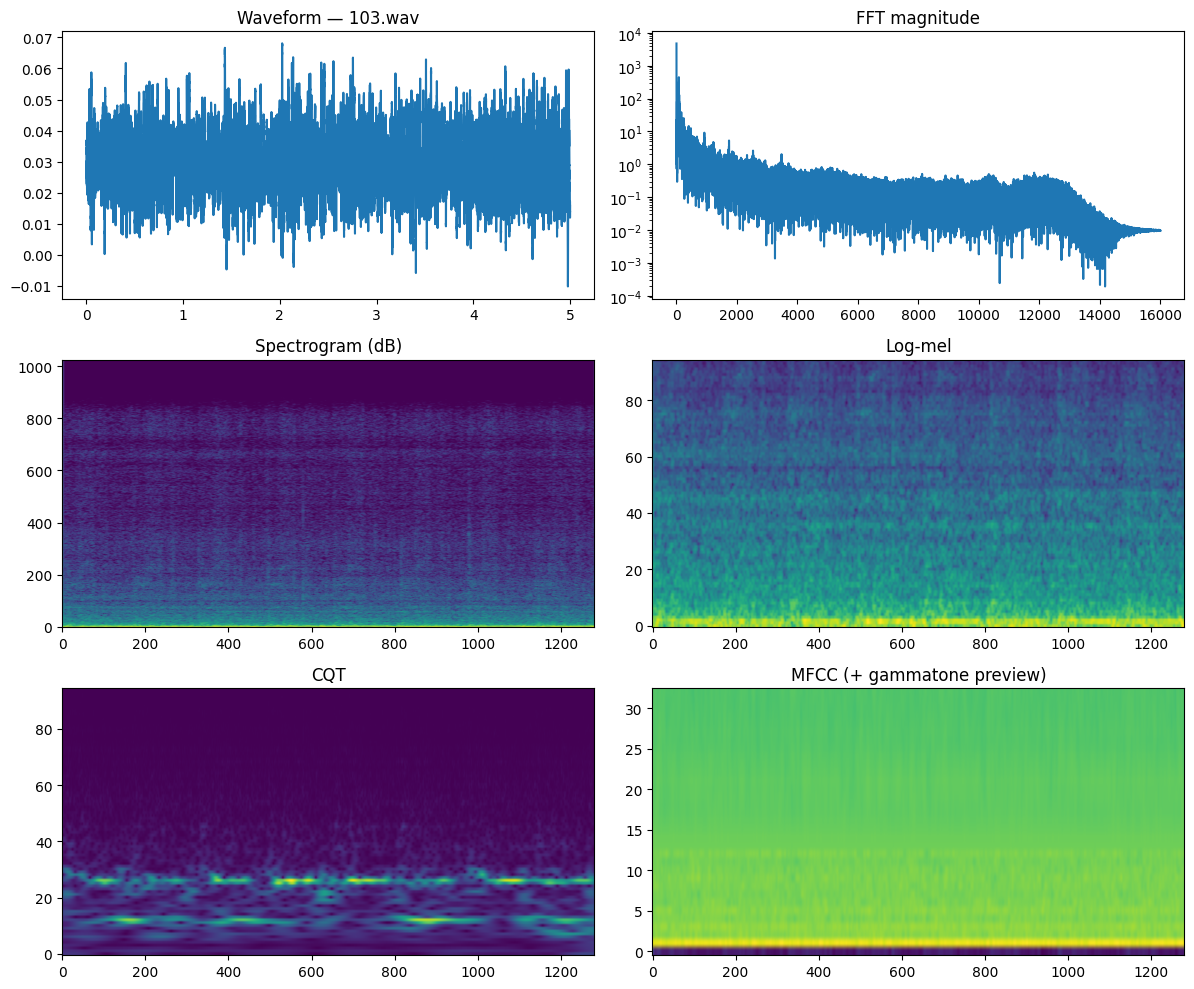

sr= 32000 n= 160000 cfg= {'sample_rate': 32000, 'hop_length': 125, 'n_bins': 95, 'n_mfcc': 13, 'fmin': 18.0, 'fmax': 4186.0}
### qiandaoear22


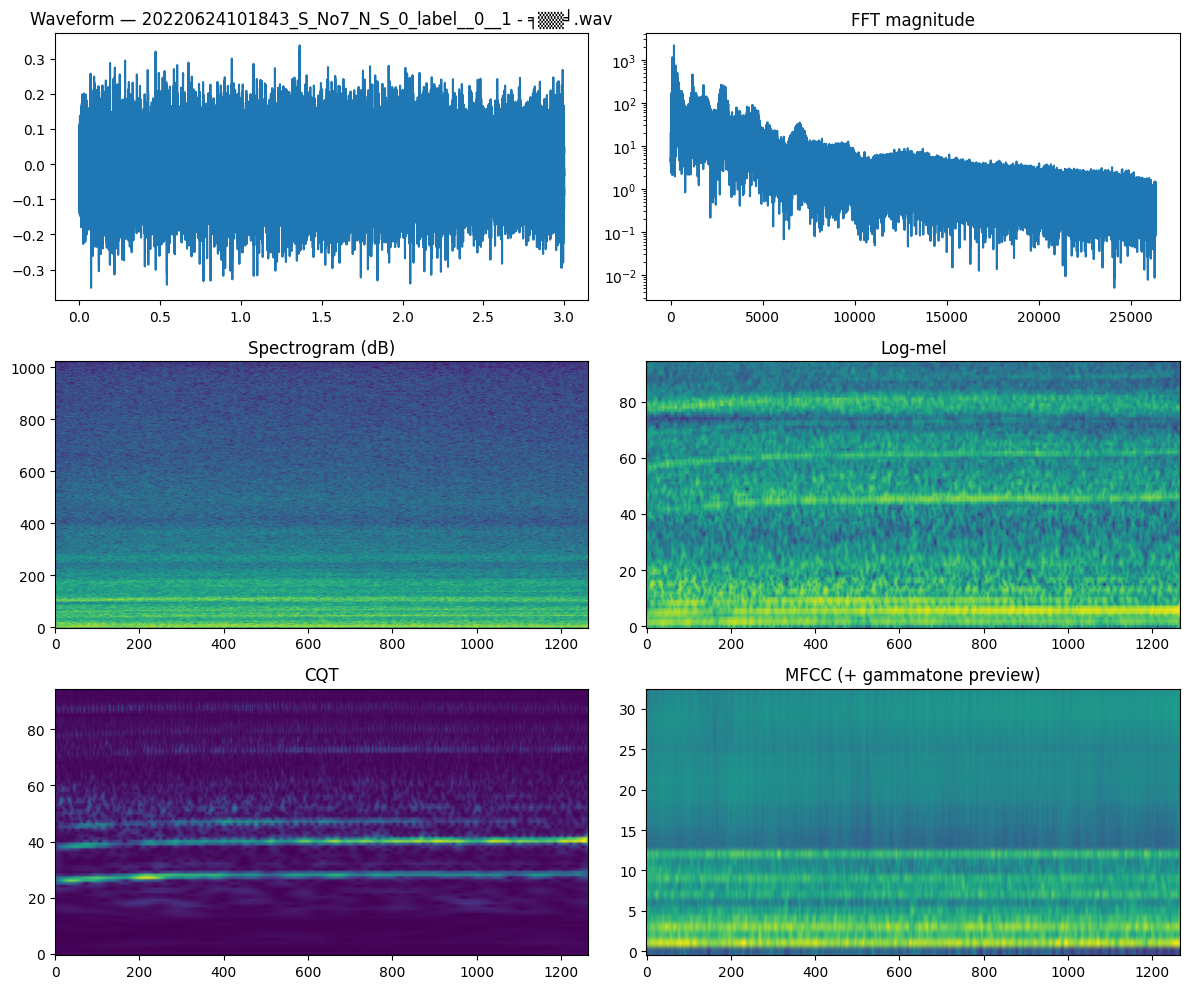

sr= 52734 n= 158202 cfg= {'sample_rate': 32000, 'hop_length': 125, 'n_bins': 95, 'n_mfcc': 13, 'fmin': 18.0, 'fmax': 4186.0}
### shipsear
No audio yet under data/raw/shipsear


In [3]:
any_files = False
for ds, files in repr_files.items():
    print('###', ds)
    if not files:
        print('No audio yet under data/raw/' + ds)
        continue
    any_files = True
    for f in files:
        inspect_file(f)

if not any_files:
    print('No datasets downloaded yet. Run scripts/download/*.py and place audio under data/raw/.')